In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from src.research.qcut_analyzer import QcutAnalyzer
# QcutAnalyzer.plot_qcut_analysis(df, col_a='Factor_A', col_b='Return')
%load_ext autoreload
%autoreload 2
from sdk_core import configure
from sdk_core import TwMarketData
# configure()
from src.research.rolling_model import train_and_predict_ridge_rolling

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from src.research.backTest import BackTest


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260521.parquet' '20260522.parquet' '20260525.parquet'
 '20260526.parquet' '20260527.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[-300:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 150
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(6)
        stock_df['ToOpen'] = ((stock_df['BidPrice1'] - stock_df.Open) / stock_df.Open ).round(6)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > -0.015) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 300/300 [01:17<00:00,  3.89it/s]


In [4]:
import gc

if 'signal_df' in locals():
    del signal_df
    gc.collect()

signal_df = pd.concat(data, ignore_index=True, copy=False)

priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)


/tmp/ipykernel_3636817/2134462285.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  signal_df = pd.concat(data, ignore_index=True, copy=False)


,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2025-03-05 09:00:09.341396,1101,108736,259,34.70,82,34.75,12,34.70,35.25,34.6,35.15,34.65,1.0,-129.682997,0.002890,-253,93.0,NaN,None,NaT
1,2025-03-05 09:00:14.694075,1101,117151,276,34.75,1,34.80,162,34.80,35.25,34.6,35.15,34.65,1.0,-115.107914,0.004335,-240,93.0,NaN,None,NaT
2,2025-03-05 09:00:47.232752,1101,176306,456,34.80,1,34.85,17,34.80,35.25,34.6,35.15,34.65,1.0,-100.574713,0.005780,-92,93.0,NaN,None,NaT
3,2025-03-05 09:00:47.240770,1101,176330,460,34.75,86,34.85,15,34.80,35.25,34.6,35.15,34.65,2.0,-115.107914,0.004335,-96,93.0,NaN,None,NaT
4,2025-03-05 09:00:47.256668,1101,176389,460,34.80,8,34.85,15,34.80,35.25,34.6,35.15,34.65,1.0,-100.574713,0.005780,-96,93.0,NaN,None,NaT
5,2025-03-05 09:00:55.301510,1101,188896,476,34.85,1,34.90,54,34.85,35.25,34.6,35.15,34.65,1.0,-86.083214,0.007225,-80,93.0,NaN,None,NaT
6,2025-03-05 09:00:56.454632,1101,190803,477,34.80,19,34.90,54,34.85,35.25,34.6,35.15,34.65,2.0,-100.574713,0.005780,-81,93.0,NaN,None,NaT
7,2025-03-05 09:00:58.761102,1101,194327,477,34.85,1,34.90,60,34.85,35.25,34.6,35.15,34.65,1.0,-86.083214,0.007225,-81,93.0,NaN,None,NaT
8,2025-03-05 09:00:58.795821,1101,194374,478,34.80,18,34.90,60,34.85,35.25,34.6,35.15,34.65,2.0,-100.574713,0.005780,-82,93.0,NaN,None,NaT
9,2025-03-05 09:00:59.633876,1101,195662,508,34.85,1,34.90,28,34.90,35.25,34.6,35.15,34.65,1.0,-86.083214,0.007225,-52,93.0,NaN,None,NaT


In [5]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)& (signal_df.SpreadPairElapsed > 0.1) ].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].sort_values(['Date', 'QuoteCode', 'TransTime']).reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

<Axes: xlabel='Date'>

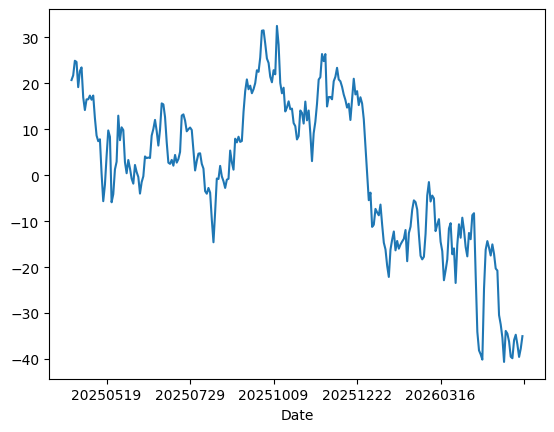

In [6]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sharpe_byThreshold( df, threshold_list, feature ) :
    
    rolling_sharpe_results = pd.DataFrame()

    for i in range(len(threshold_list)-1):
        thr =  threshold_list[i]
        thr_ =  threshold_list[i+1]

        temp_df = signal_df[ (signal_df[feature] > thr) & (signal_df[feature] < thr_) ].copy()
        
        # 1. 算每天每檔商品的淨 BP (第一層)
        item_daily_bp = temp_df.groupby(['Date', 'QuoteCode'])['TakerSell_CloseBP'].mean()
        
        # 2. 算全市場單日的期望值 EV (Mean)
        daily_ev = item_daily_bp.groupby(level='Date').mean()#.rolling(30).mean()
        
        # 3. 【新增】算全市場單日的橫斷面波動率 (Std)
        daily_std = item_daily_bp.groupby(level='Date').std()#.rolling(30).mean()
        
        # 為了避免某天只有一檔商品導致 std 為 NaN 或 0，做個防呆
        daily_std = daily_std.replace(0, np.nan).ffill().fillna(1)
        
        # 4. 【核心指標】計算單日訊號夏普值 (EV / 波動率)
        daily_sharpe = daily_ev / daily_std

        sorted_vals = daily_sharpe.dropna().sort_values()
        
        if len(sorted_vals) >= 2:
            min_val = sorted_vals.iloc[0]      # 最小值 (異常值)
            sec_min_val = sorted_vals.iloc[1]  # 次小值 (正常低點)
            
            # 2. 判斷邏輯：如果最小值比「次小值的 5 倍」還要更小 (假設是負數，例如 -50 < -10 * 5)
            # (如果次小值是正數但最小值是極端負數，這個邏輯也能完美攔截)
            if min_val < (sec_min_val * 2):
                # 3. 將這個極端值取代為 NaN
                daily_sharpe = daily_sharpe.replace(min_val, sec_min_val)
        
        # 5. 平滑化 (Rolling 30)
        rolling_sharpe = daily_sharpe.rolling(30).mean()
        
        rolling_sharpe_results[f' {thr} ~ {thr_}'] = rolling_sharpe

    # 畫圖
    rolling_sharpe_results.index = pd.to_datetime(rolling_sharpe_results.index)

    # ----------------- 下面是你原本的畫圖語法 -----------------
    sns.set_theme(style="darkgrid", context="talk")
    fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

    sns.lineplot(data=rolling_sharpe_results.iloc[30:], palette="tab10", linewidth=2, ax=ax)

    # 畫一條 y=0 的生死線
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_title(f'Rolling 30-Day Signal Sharpe Ratio (EV / Std) by {feature}', fontsize=16, pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Risk-Adjusted Return (Sharpe)', fontsize=12)

    # 因為已經轉成時間格式，這個自動排版函數才能發揮作用！
    fig.autofmt_xdate(rotation=45) 
    ax.legend(title=f'{feature} Thresholds', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.subplots_adjust(right=0.85)

    plt.show()

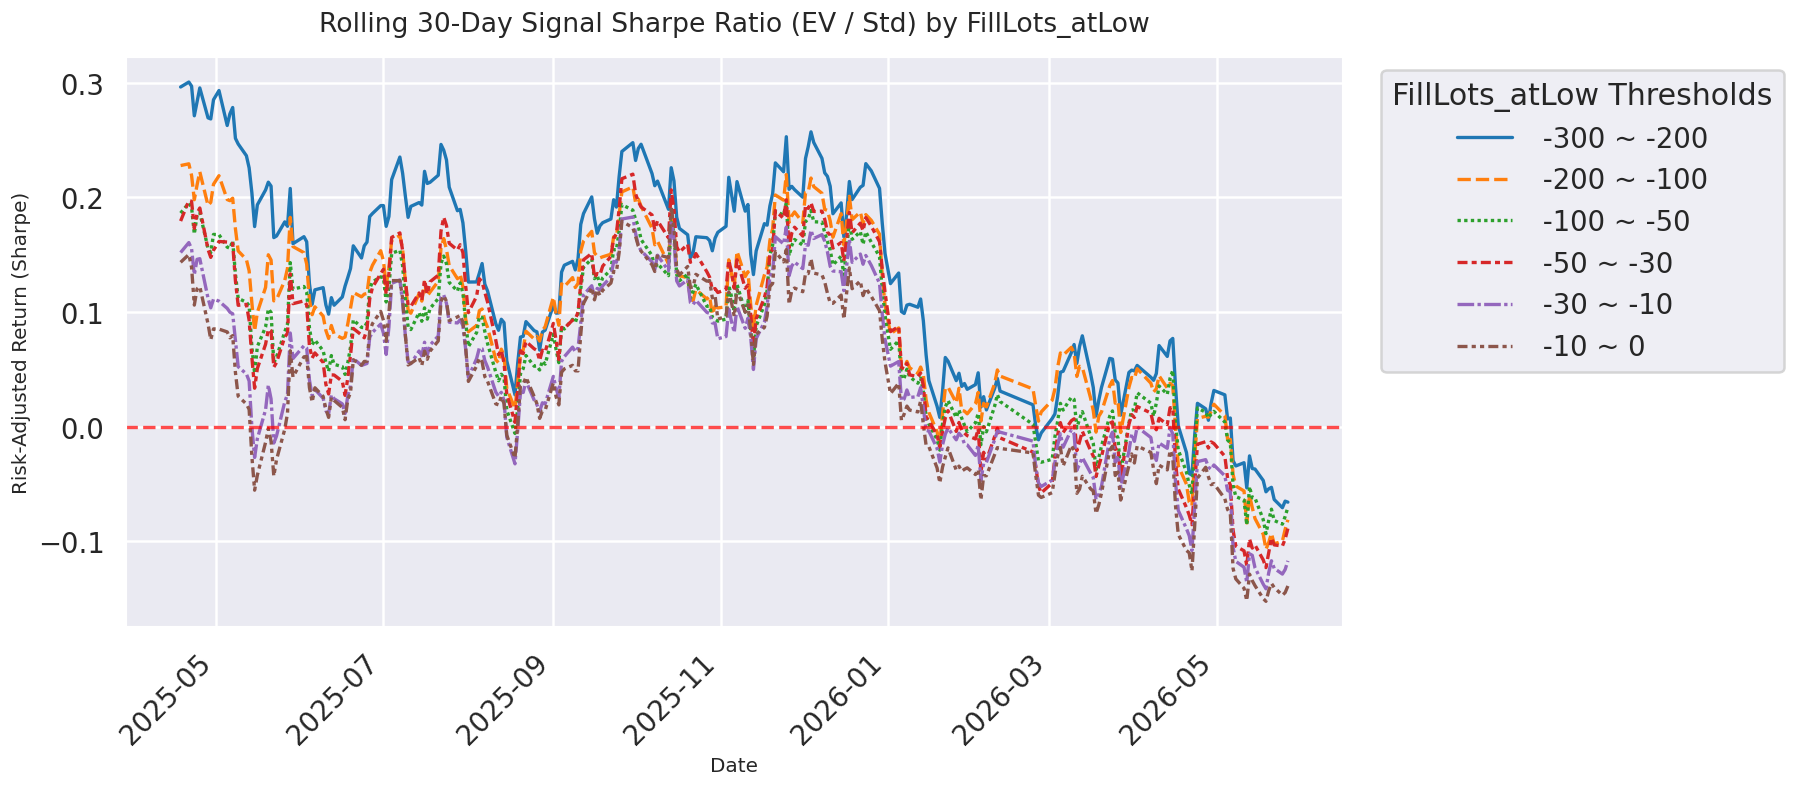

In [8]:
plot_sharpe_byThreshold( signal_df, [-300,-200,-100,-50,-30,-10,0], feature='FillLots_atLow')


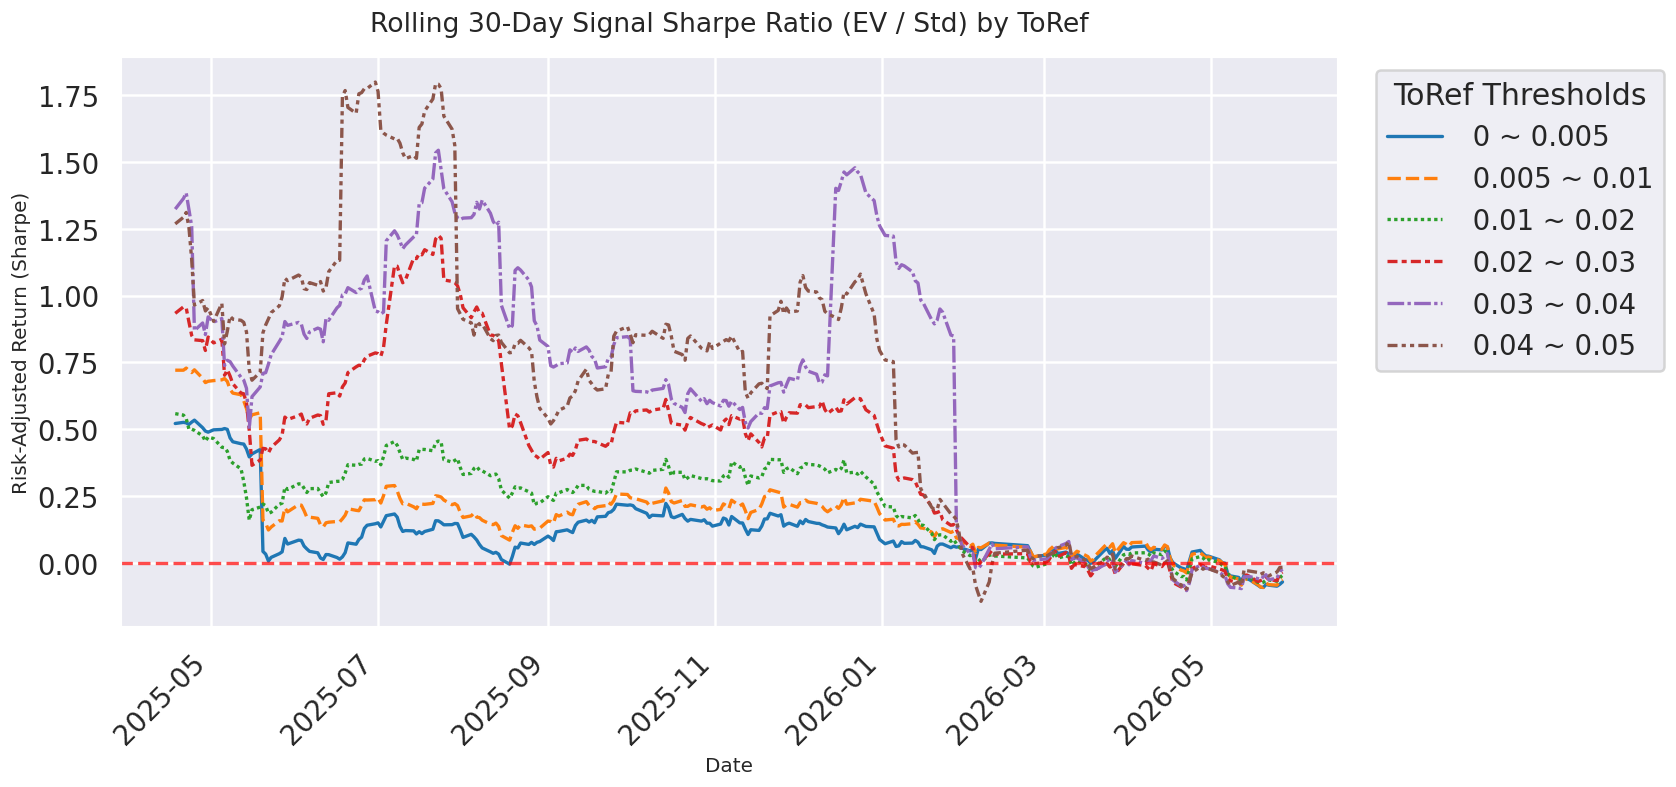

In [9]:
plot_sharpe_byThreshold( signal_df, [0,0.005,0.01,0.02,0.03,0.04,0.05], feature='ToRef')


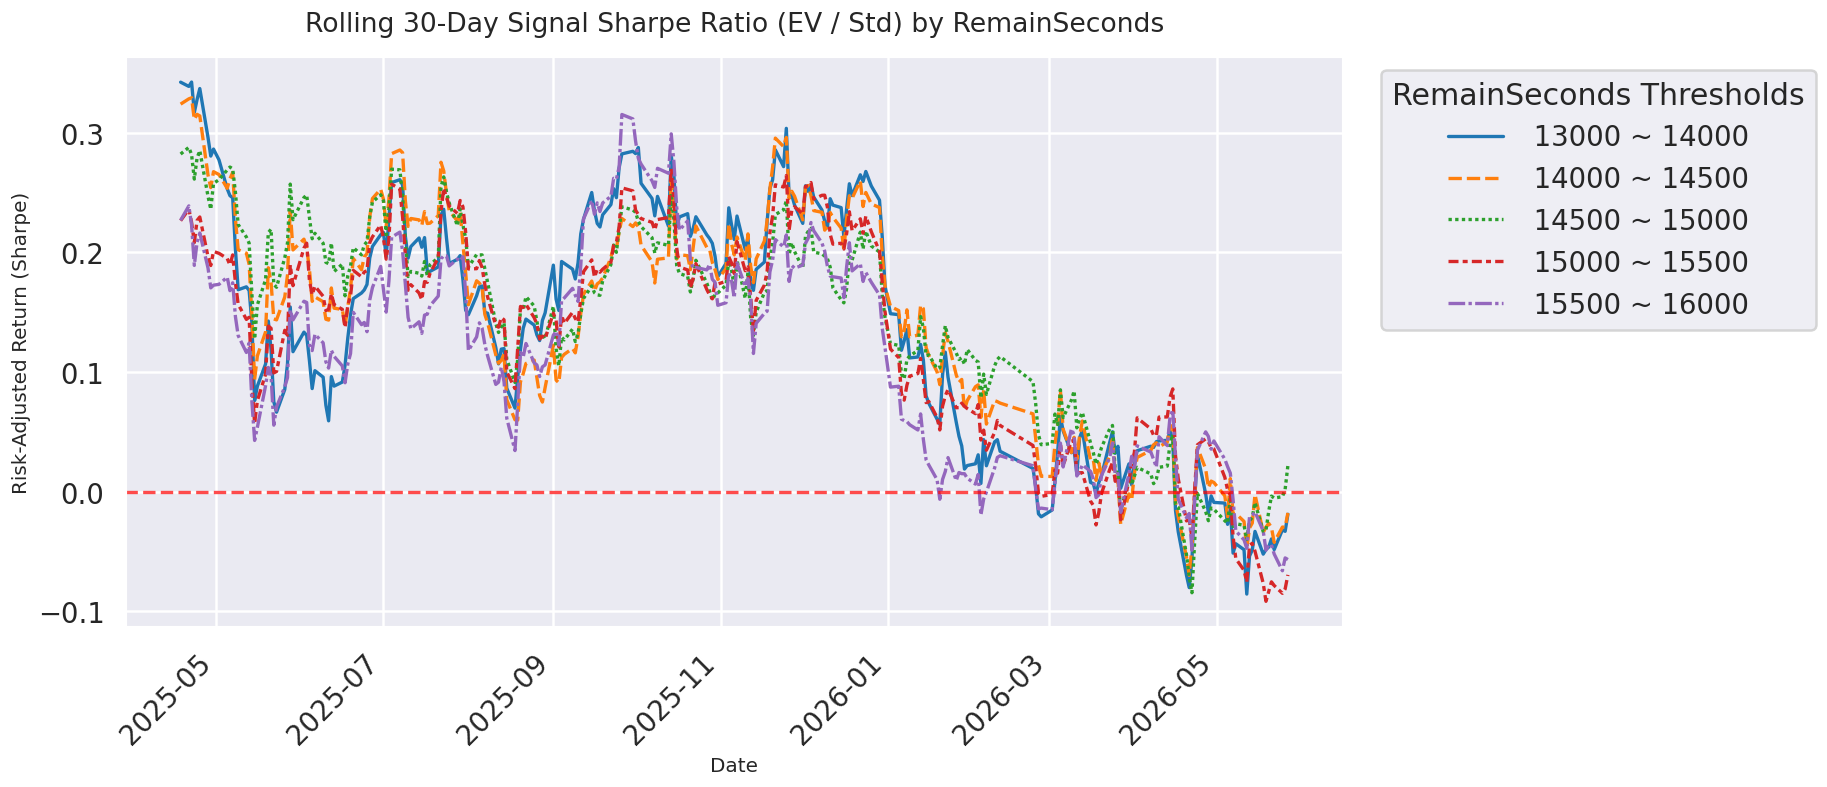

In [10]:
plot_sharpe_byThreshold( signal_df, [13000,14000,14500,15000,15500,16000], feature='RemainSeconds')

In [11]:
signal_df['OpenGap'] = (signal_df.Open - signal_df.RefPrice)/signal_df.RefPrice

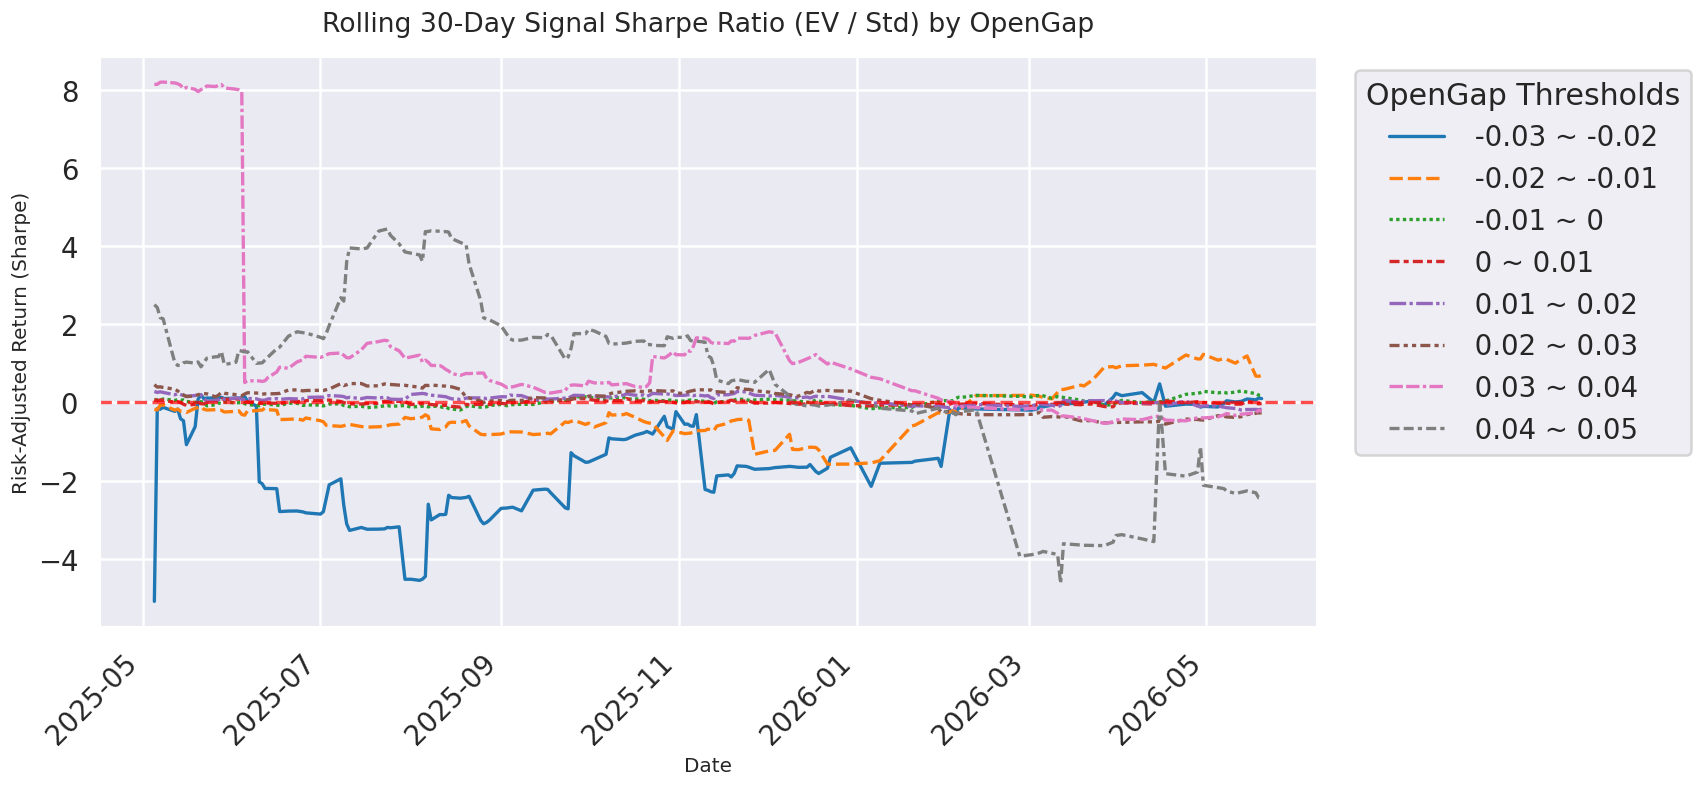

In [12]:
plot_sharpe_byThreshold( signal_df, [-0.03,-0.02,-0.01,0,0.01,0.02,0.03,0.04,0.05] ,feature='OpenGap')

In [13]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')- (signal_df.FutureHigh > signal_df.RefPrice *1.08) * 20#.clip(lower=-130, upper=130)
signal_df['TakerSell_CloseBP_netM'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')- (signal_df.FutureHigh > signal_df.RefPrice *1.08) * 20#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')

In [14]:
import pandas as pd
import json

# 1. 讀取 JSON 檔案還原成 list
with open('abnormal_dates.json', 'r') as f:
    loaded_date_list = json.load(f)

signal_df['isAbnormalDate'] = (signal_df['Date'].isin(loaded_date_list) ) *1 
# signal_df.loc[ signal_df.Date == signal_df.Date.max(), 'isAbnormalDate'] = 1 


In [15]:
signal_df['B2_Last'] = signal_df.BidLots2 / signal_df.avg_bidLots1
signal_df['A2_Last'] = signal_df.AskLots2 / signal_df.avg_askLots1

signal_df['B1_B12'] = signal_df.BidLots1 / (signal_df.BidLots1+signal_df.BidLots2)
signal_df['A1_A12'] = signal_df.AskLots1 / (signal_df.AskLots1+signal_df.AskLots2)
signal_df['B45_AB45'] = (signal_df.BidLots4 + signal_df.BidLots5 ) / (signal_df.AskLots4 + signal_df.AskLots5 + signal_df.BidLots4 + signal_df.BidLots5 )

signal_df['Total_Last'] = signal_df.TotalFillLots / signal_df.last_fillLots
signal_df['TickBP'] = signal_df.TickSize / signal_df.BidPrice1 * 10000
signal_df['LOB_BidVelocity_30_re'] = signal_df.LOB_BidVelocity_30.abs() / signal_df.avg_bidLots1
signal_df['LOB_AskVelocity_30_re'] = signal_df.LOB_AskVelocity_30.abs() / signal_df.avg_askLots1

signal_df['L1_SellBiggestLots_30_re'] = signal_df.L1_SellBiggestLots_30.abs() / signal_df.big_sell_lots
signal_df['L1_BuyBiggestLots_30_re'] = signal_df.L1_BuyBiggestLots_30.abs() / signal_df.big_buy_lots 

signal_df['MD_ElaspeTime_30_re'] = (signal_df.MD_ElaspeTime_30+1).apply(np.log)
signal_df['MD_L1Rate_30_re'] = signal_df.MD_L1Rate_30


In [16]:
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'RemainSeconds']#'B1_Last','Total_Last']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns
label = 'TakerSell_CloseBP_net'
# feature_columns = ['ToLow', 'ToHigh', 'Low_High',  'RemainSeconds',  'FillLots_atLow', 'FillLots_atHigh', 'ToOpen', 'ToRef',
#   'B1_A1B1', 'B1_B1B5', 'A1_A1A5', 'B2_Last', 'A2_Last','Total_Last','B45_AB45','B1_B12','A1_A12' , 'QL_BidHHI', 'QL_AskHHI'
# ] + signal_df.columns[ (signal_df.columns.str.contains('_re')) & ~(signal_df.columns.str.contains('2330')) ].tolist()
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'ToRef', 'ToOpen', 'B1_A1B1', 'RemainSeconds', 'MD_ElaspeTime_30_re','MD_L1Rate_30']#, 'L1_SellBiggestLots_30','L1_BuyBiggestLots_30','MD_ElaspeTime_30','MD_L1Rate_30'] #
# day_columns = ['foreign_netLots', 'investment_netLots','margin_netLots','turnover_rate','hft_strick_makerSpreadBP','hft_strick_participation','hft_participation','big_sell_ToCloseBP']

In [17]:
for c in feature_columns : 
    signal_df[c] = signal_df[c].round(6)
signal_df ['OTC'] = signal_df ['OTC'] * 1
signal_df ['isInvestBuy'] = ( ( signal_df ['investment_netLots']  > 1000) & (signal_df.OTC == True) ) * 1 

🔍 目前預測目標: TakerSell_CloseBP_net | Rolling Training 視窗: 60 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 2061245
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
----------------------------------------
🚀 總輸入 current_X (共 9 個)
   - Tick Baseline: 9 個
   - Day Features:  0 個
   - Forced Masks:  0 個
----------------------------------------
🔄 計算 Lot Mask 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker: 16)...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    4.9s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！
▶️ Phase 2: Rolling Update (Core: -1)...


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   16.9s
[Parallel(n_jobs=-1)]: Done 268 out of 300 | elapsed:   20.2s remaining:    2.4s


✅ 平行 Rolling 更新預測完成！
  Rolling Model Dashboard — NORMAL Model
  交易日數: 299  |  特徵數: 9
  Feature Screening: ON (112/299 天有篩選)

📊 [1/4] Feature Selection Frequency


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   21.6s finished


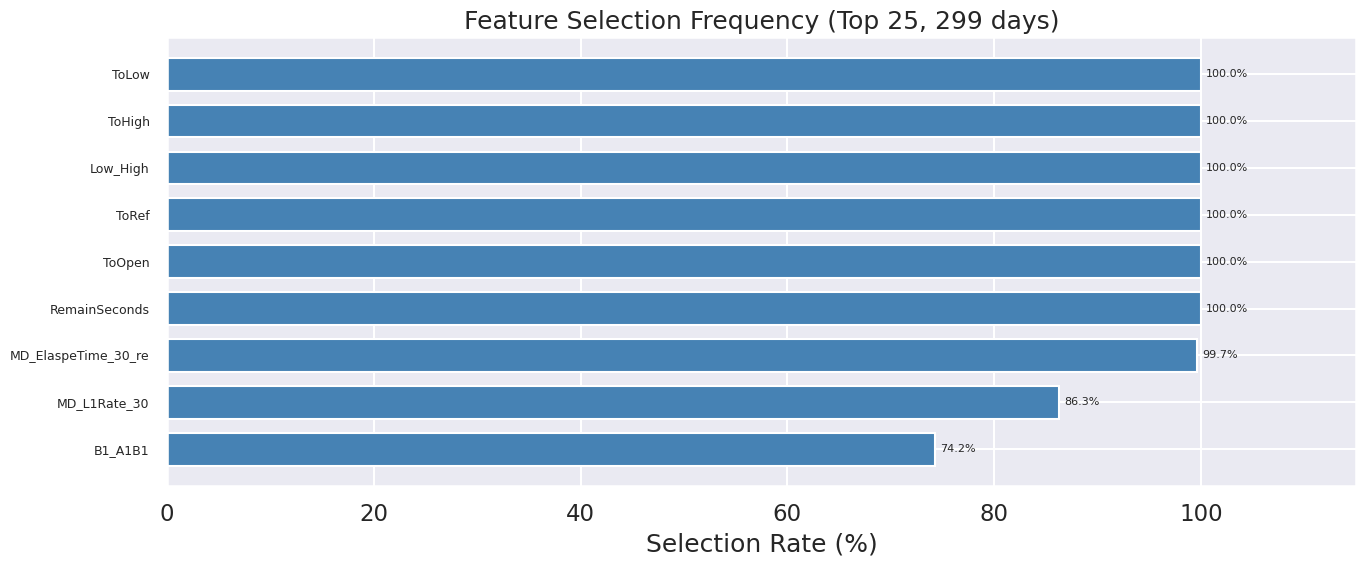


📊 [2/4] Feature Selection Heatmap


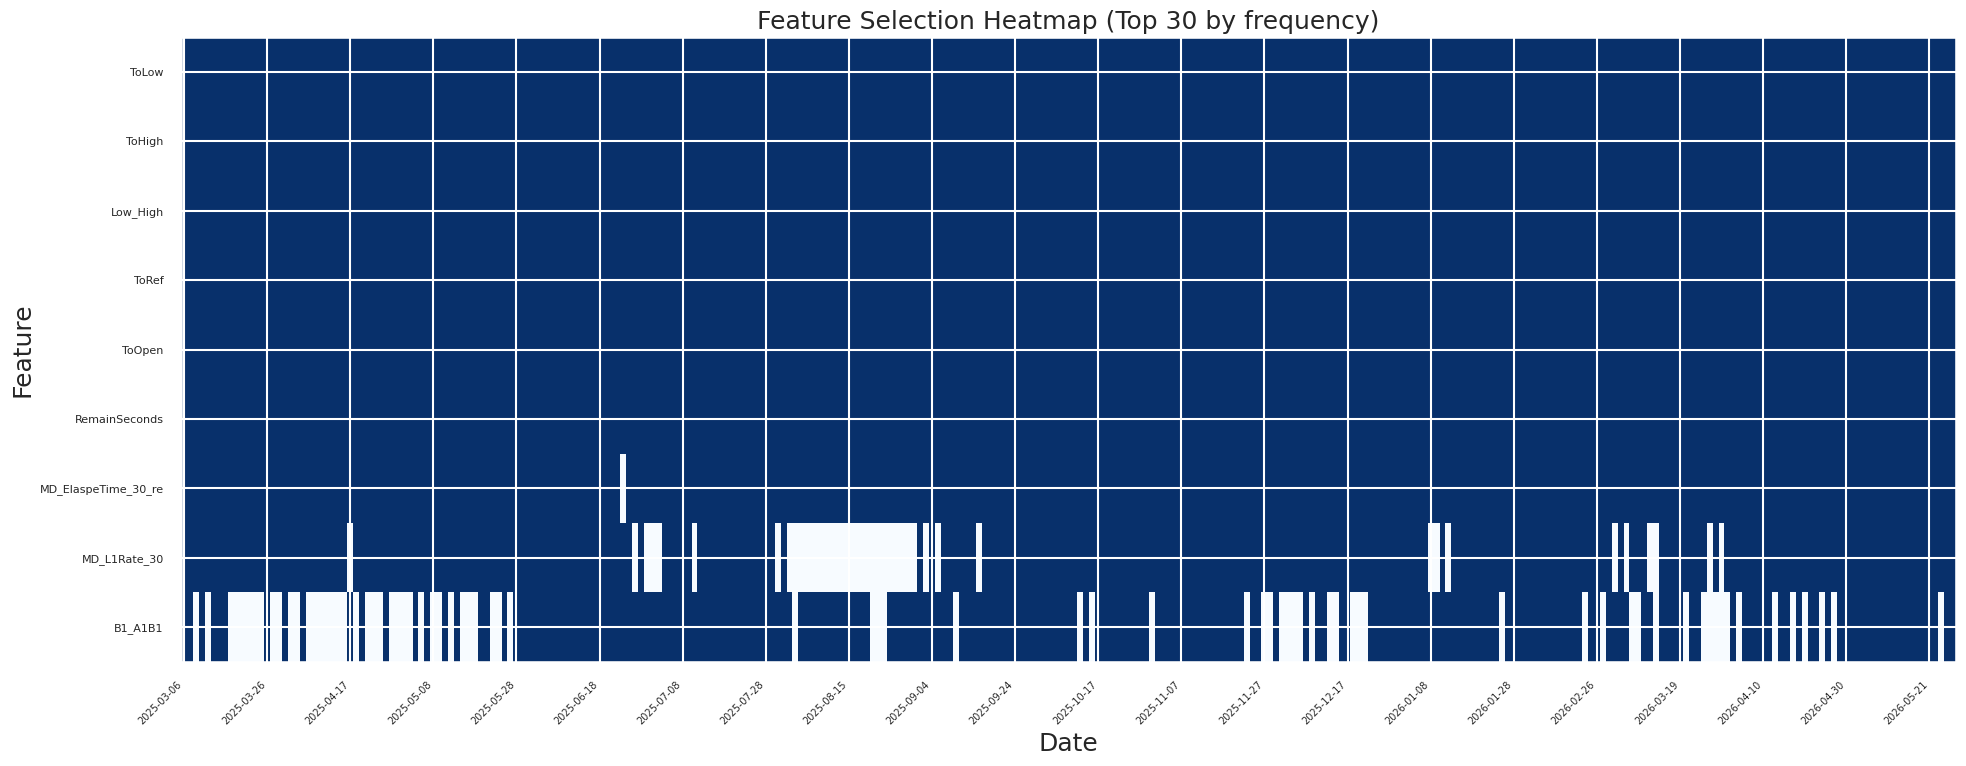


📊 [3/4] Standardized Coefficient Importance


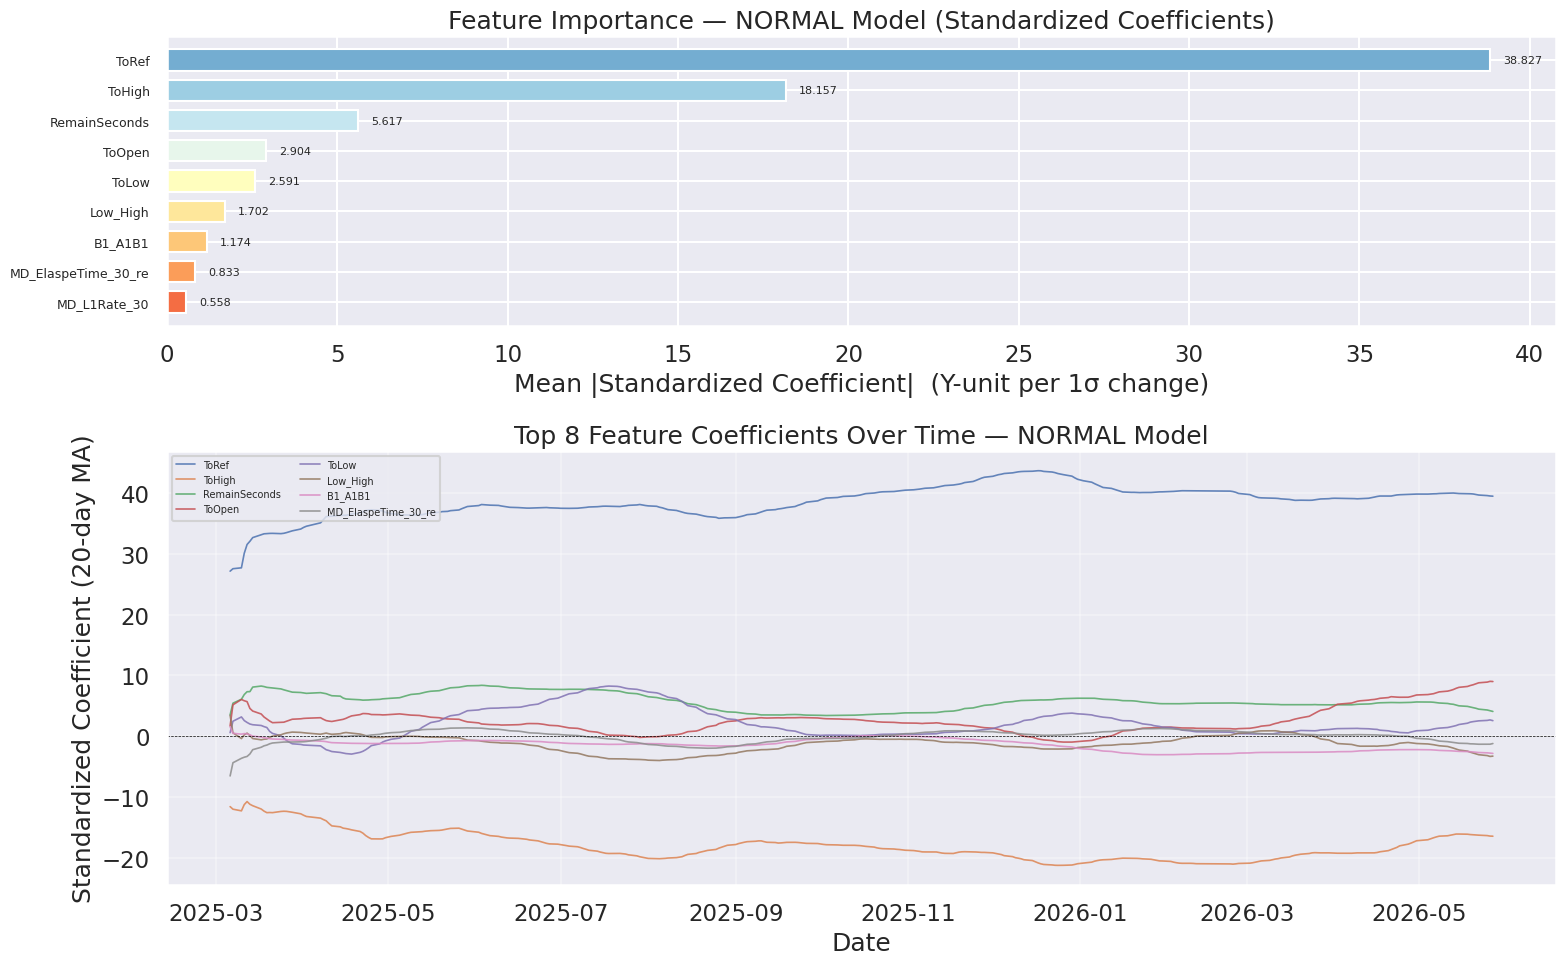


📊 [4/4] Coefficient Stability


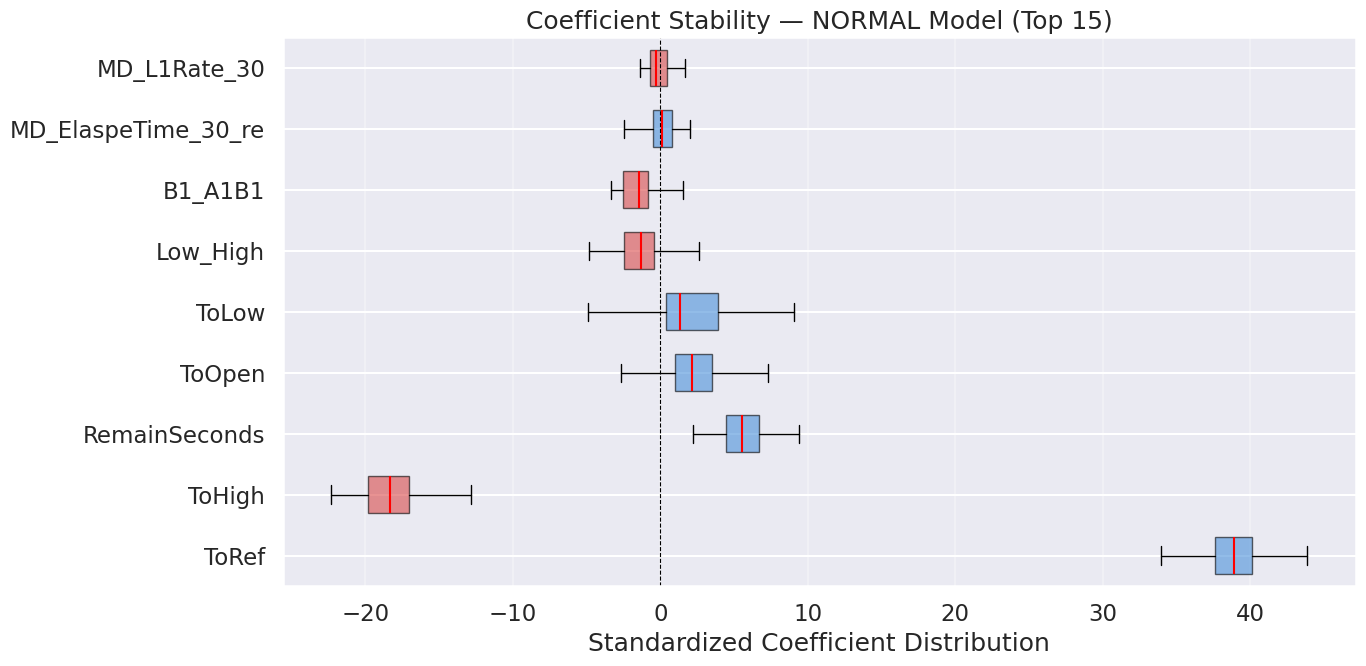

🔍 目前預測目標: TakerSell_CloseBP_netM | Rolling Training 視窗: 20 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 2061245
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
----------------------------------------
🚀 總輸入 current_X (共 9 個)
   - Tick Baseline: 9 個
   - Day Features:  0 個
   - Forced Masks:  0 個
----------------------------------------
🔄 計算 Lot Mask 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker: 16)...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！
▶️ Phase 2: Rolling Update (Core: -1)...


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 268 out of 300 | elapsed:    4.6s remaining:    0.5s


✅ 平行 Rolling 更新預測完成！
  Rolling Model Dashboard — NORMAL Model
  交易日數: 299  |  特徵數: 9
  Feature Screening: ON (292/299 天有篩選)

📊 [1/4] Feature Selection Frequency


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    4.8s finished


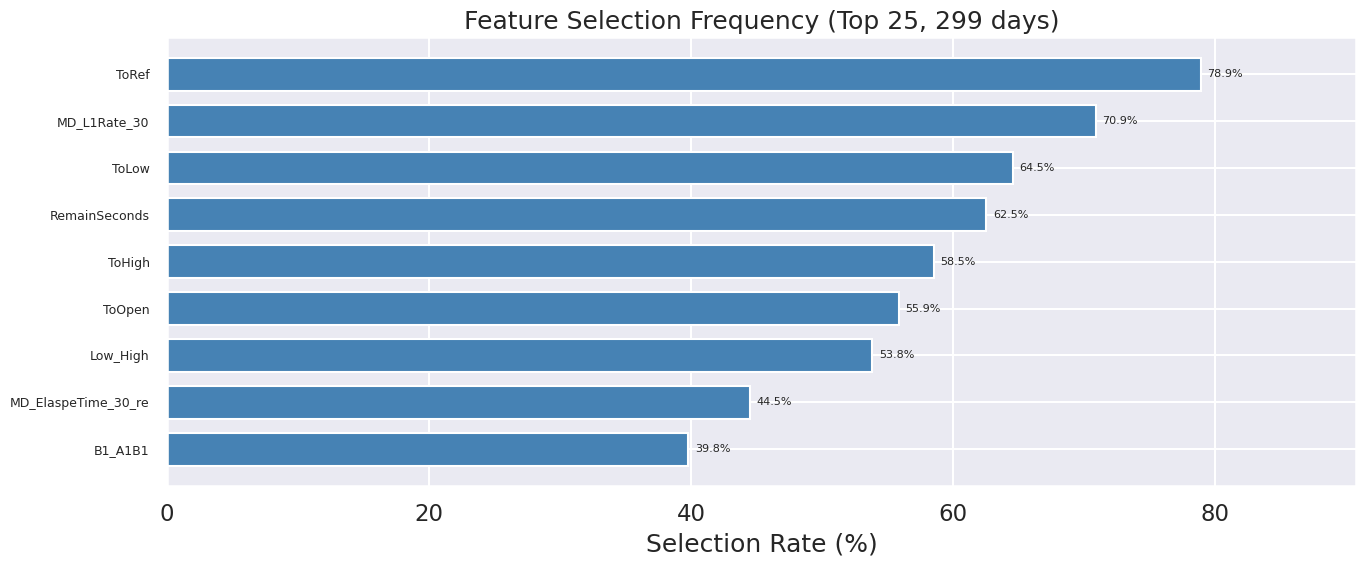


📊 [2/4] Feature Selection Heatmap


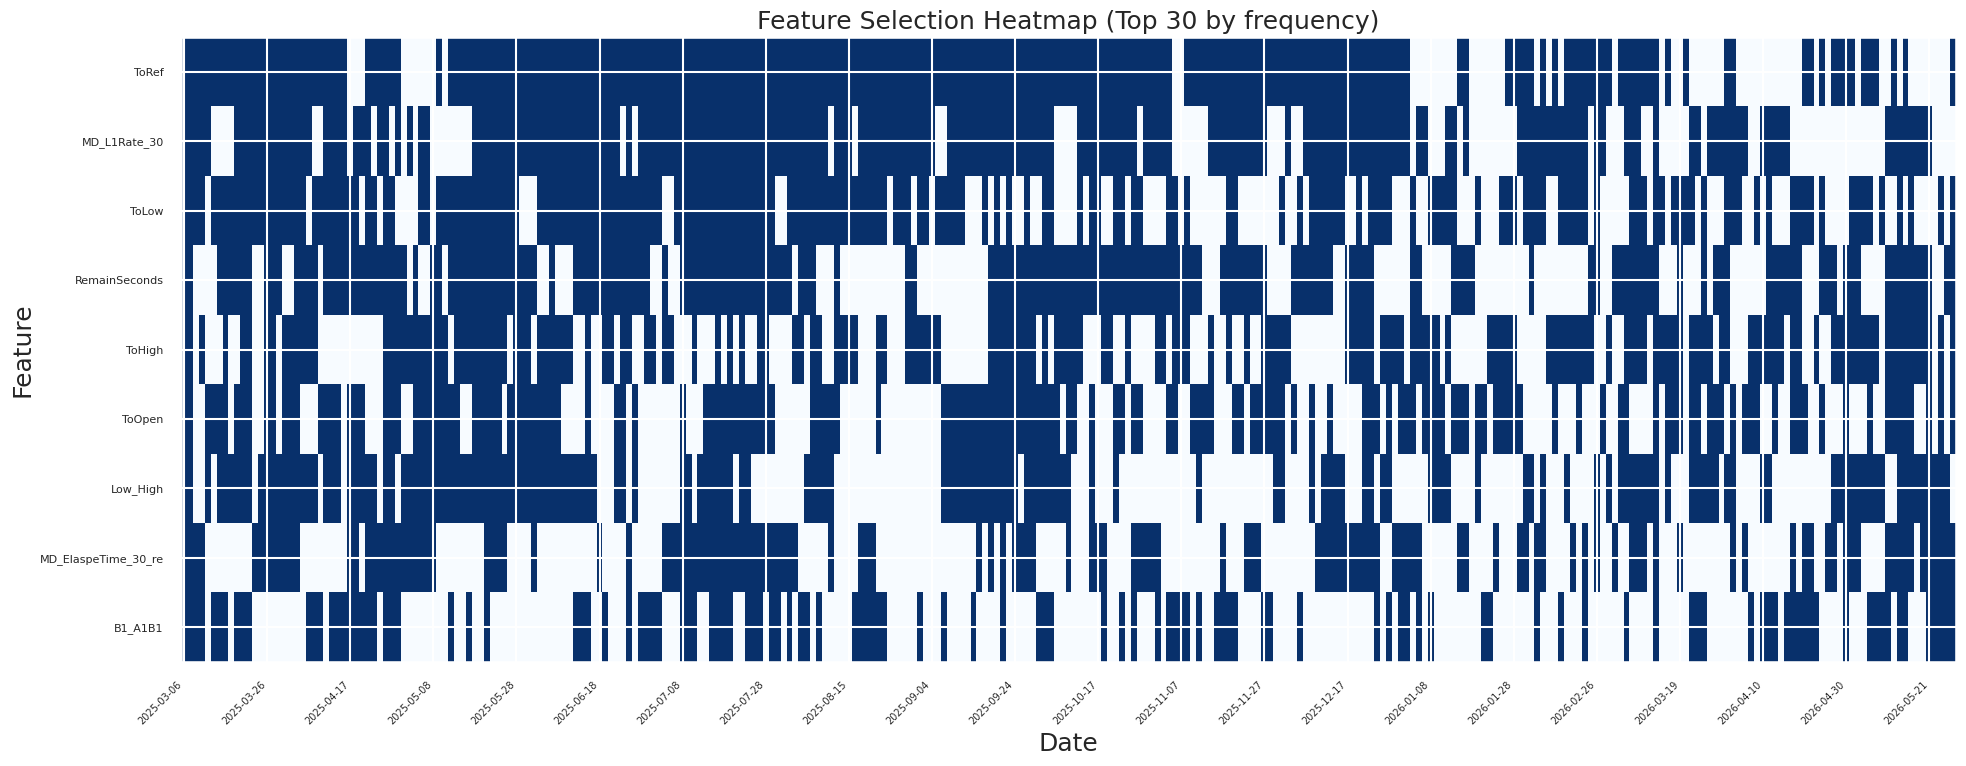


📊 [3/4] Standardized Coefficient Importance


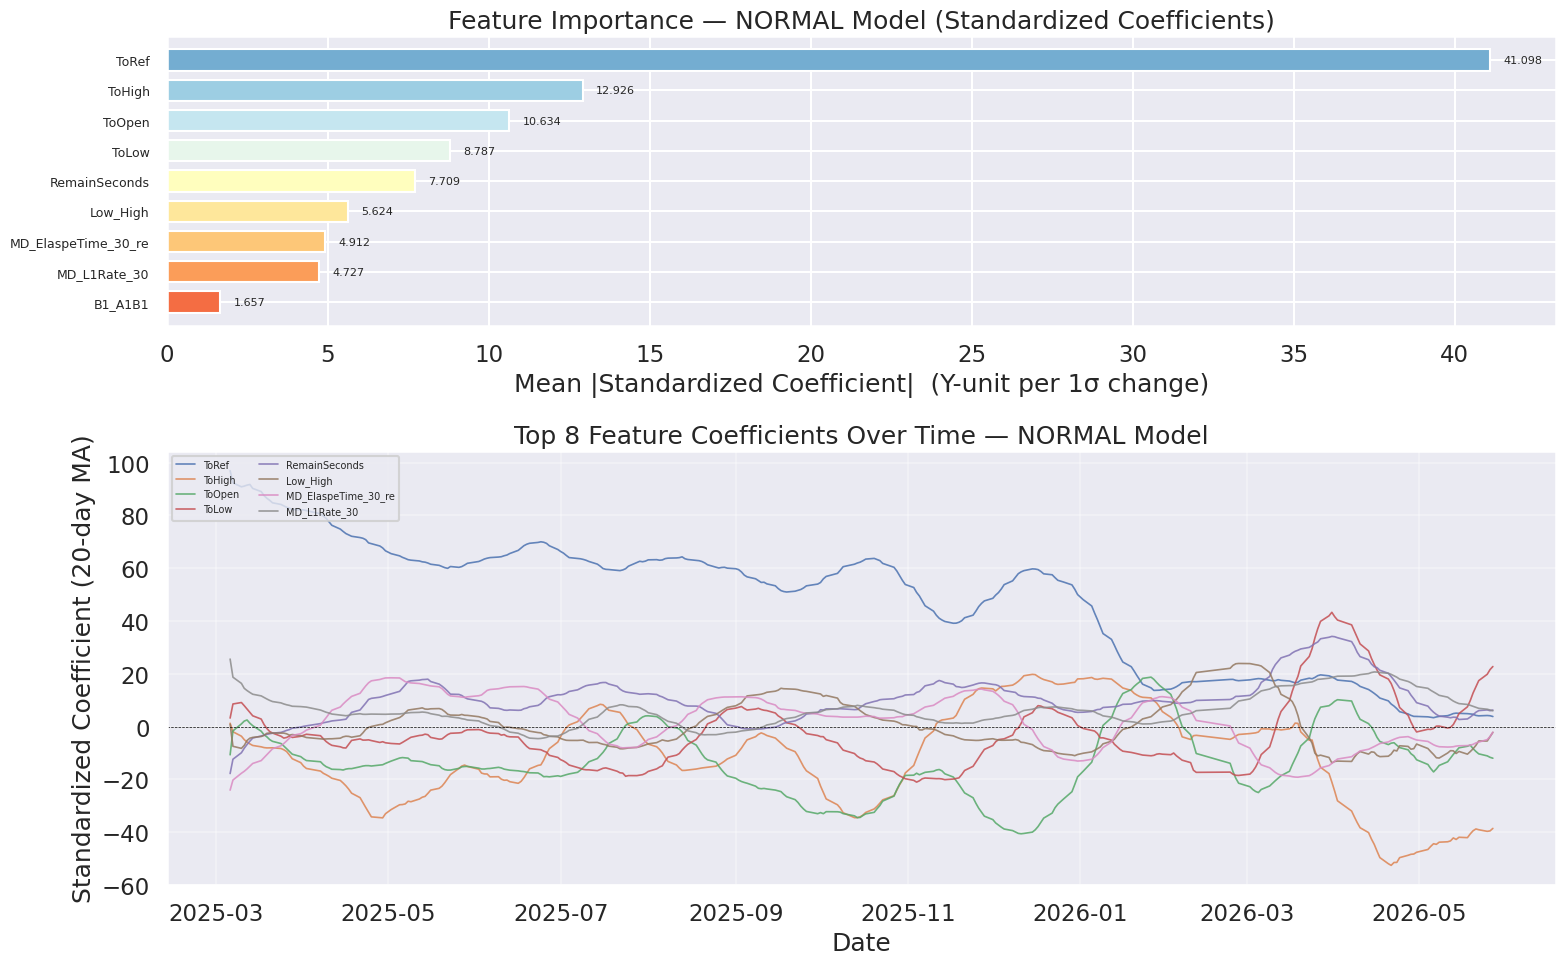


📊 [4/4] Coefficient Stability


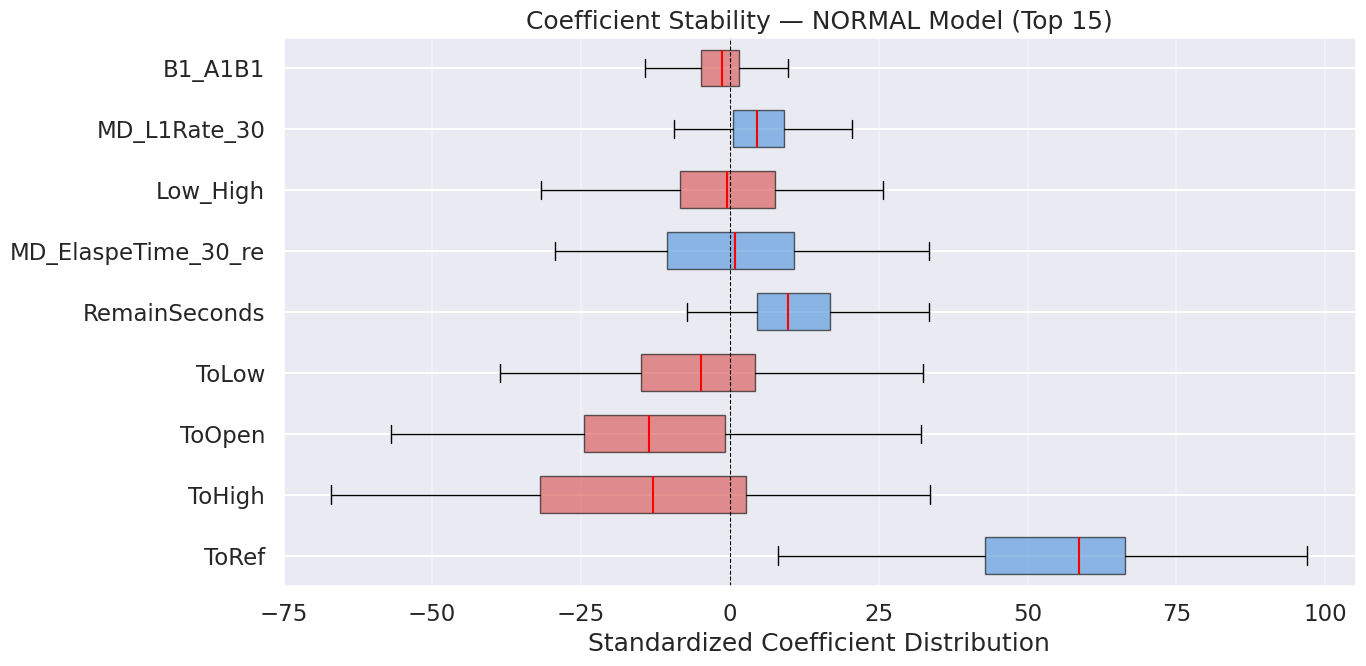

In [18]:
day_columns = []
from src.research.negFill.model_analysis import plot_model_dashboard

# result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label,  n_training_days=20,  day_features= day_columns, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label,  n_training_days=60,  day_features= day_columns, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}day_features= day_columns, day_features= day_columns,
signal_df = result['df']           # 原本的 DataFrameㄌ
plot_model_dashboard(result, model_type='normal')

# day_columns = ['foreign_netLots', 'investment_netLots','margin_netLots','turnover_rate','hft_strick_makerSpreadBP','hft_strick_participation','hft_participation','big_sell_ToCloseBP']
result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label+'M', n_training_days=20,  day_features= day_columns, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}
signal_df = result['df']
plot_model_dashboard(result, model_type='normal')


coeff_log

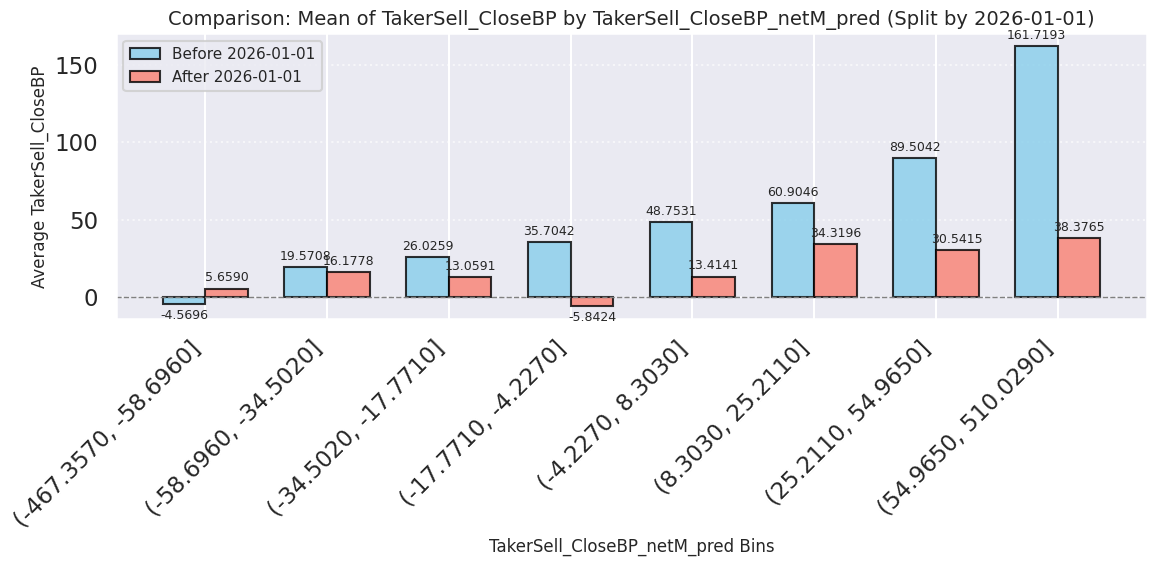

In [19]:
# QcutAnalyzer.plot_qcut_analysis(signal_df.assign( TakerSell_CloseBP_net_pred = signal_df.TakerSell_CloseBP_net_pred + signal_df['20day_marketBeta'])[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)
QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_netM_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)
# QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)


In [20]:
from matplotlib.pyplot import contour
from os import execve
for c in signal_df.columns :
    try :
        QcutAnalyzer.plot_qcut_analysis(signal_df_model[(signal_df_model.OTC !=1) ], c , 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01', q=8)
    except : 
        continue

new_feature = [
    "MD_L1Rate_10", "MD_L1Rate_30", "MD_L1Rate_100",
    "MD_ElaspeTime_10", "MD_ElaspeTime_30", "MD_ElaspeTime_100",
    "MD_hftRate_10", "MD_hftRate_30", "MD_hftRate_100",
    "A3_OrderAmtChg_30", "A3_OrderAmtChg_100",
    "B3_OrderAmtChg_30", "B3_OrderAmtChg_100",
    "L1_InOutRate_10", "L1_InOutRate_30",
    "L1_BuyBiggestLots_10", "L1_BuyBiggestLots_30",
    "L1_SellBiggestLots_10", "L1_SellBiggestLots_30",
    "MD_OvershootBuy_30", "MD_OvershootSell_30",
    "QL_BidHHI", "QL_AskHHI",
    "LOB_BidVelocity_10", "LOB_BidVelocity_30",
    "LOB_AskVelocity_10", "LOB_AskVelocity_30",
    "ICE_AskReplenish_30", "ICE_AskReplenish_100",
    "ICE_BidReplenish_30", "ICE_BidReplenish_100",
    "TC_Streak", "TC_BurstLots_10", "TC_BurstLots_30",
    "IA_BuyImpact_30", "IA_SellImpact_30",
    "IA_BuyImpact_100", "IA_SellImpact_100",
    "RES_Bounce_30", "RES_Bounce_100",
    "DIV_10", "DIV_30",
    "CTC_MarketDir_500", "CTC_MarketDir_2000",
    "CTC_Agreement_500", "CTC_Agreement_2000",
    "CTC_TimeSpan_500", "CTC_TimeSpan_2000",
]
for c in new_feature : 
    QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate != 5], c , 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01', q=8)


In [21]:
from numpy._core.defchararray import upper
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
# condition = condition  & ((( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) >  40)  ) | (( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) >  60) )) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
condition = condition & ((( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) >  20) & ( signal_df.TakerSell_CloseBP_netM_pred * (signal_df.isAbnormalDate == 0 ) >  -40) ) | (( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) >  20) & ( signal_df.TakerSell_CloseBP_netM_ABpred * (signal_df.isAbnormalDate == 1 ) > -40))) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round(signal_df[condition].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date > pd.to_datetime('2026-01-01')) # & (signal_df.Date.dt.strftime('%Y%m%d').astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round(signal_df[condition_recent].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    669159.000000
mean         79.197170
std         314.502510
min        -977.037037
25%         -77.007701
50%         124.481328
75%         276.729560
max        1415.701416
Name: TakerSell_CloseBP, dtype: float64

cap BP : 62
averge prod num : 81.72
count    229964.000000
mean         27.600739
std         373.321408
min        -977.037037
25%        -226.876091
50%          43.149946
75%         271.739130
max        1415.701416
Name: TakerSell_CloseBP, dtype: float64

cap BP : 26
averge prod num : 81.9


In [22]:
# signal_df_model = signal_df[ condition  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True) #(signal_df.SpreadPairElapsed > 0.1)  &
signal_df_model = signal_df[ condition & (signal_df.ToRef > 0)  &((signal_df.AmountRank_canDayTrade<=100) |(signal_df.day_amount_rank <=100))  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True) 
# signal_df_model = signal_df[ condition & (signal_df.SpreadPairElapsed > 0.1)  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True) 

QcutAnalyzer.plot_qcut_analysis(signal_df_model, 'MD_ElaspeTime_30', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01', q=8)


signal_df[ (signal_df.Date) ==signal_df.Date.max()][signal_df.QuoteCode=='3042']


signal_df[ (signal_df.Date == pd.to_datetime('2026-04-20') ) & (signal_df.QuoteCode == '2367') &(signal_df.ChannelSeq <= 507070)][[
    'TransTime','QuoteCode','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','TakerSell_CloseBP_net_ABpred','AmountRank_canDayTrade','day_amount_rank','hft_strick_makerSpreadBP','investment_netLots','ToLow',
   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds']].tail(1)
test_row = signal_df[ (signal_df.Date == pd.to_datetime('2026-04-20') ) & (signal_df.QuoteCode == '4931') &(signal_df.ChannelSeq <= 525339)][[
    'TransTime','QuoteCode','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','TakerSell_CloseBP_net_ABpred','AmountRank_canDayTrade','day_amount_rank','hft_strick_makerSpreadBP','investment_netLots',
    'ToLow',   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds']].tail(1)
test_row

coef_view =  np.array([ -327.8939514160156, -437.1385192871094, -0.9559449553489685,	2317.24560546875,	324.37530517578125, -20.37383270263672, 0.003649163991212845])
intercept = -26.025564193725586

row_view = np.array([ test_row[x].iloc[0] for x in ['ToLow',   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds'] ])
sum(coef_view * row_view) + intercept

In [53]:
signal_df_model['PosLots'] = signal_df_model.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df_model['Position'] = signal_df_model.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df_model[  
(signal_df_model.Position < 200)
# (~((signal_df_model.PosLots >1) & (signal_df_model.Position > 50))) & (signal_df_model.BidPrice1<500) 
# ( ((signal_df_model.Position < 500)&((signal_df_model.AmountRank < 50) | (signal_df_model.day_amount_rank<50))) |((signal_df_model.Position < 200)&((signal_df_model.AmountRank < 100) | (signal_df_model.day_amount_rank<100))) | ((signal_df_model.Position < 100)))
& (signal_df_model.BidPrice1<1000) 
& ( (signal_df_model.hft_strick_makerSpreadBP > -70) | (signal_df_model.hft_strick_makerSpreadBP.isna()))
# & ((signal_df_model.investment_netLots <= 0 )) 
# & (signal_df_model.OTC !=1) #& (signal_df.big_buy_ToCloseBP < 10) #(signal_df_model.SpreadPairElapsed >2 )
#  & ((signal_df_model.ToRef>0))
      ].reset_index(drop=True)
# signalwithRisk_df = signal_df_model[ (signal_df_model.PosLots ==1) & (signal_df_model.BidPrice1 <= 100)].reset_index(drop=True)
signalwithRisk_df['Date'] = signalwithRisk_df.Date.dt.strftime('%Y%m%d')


# 1. 排序
signalwithRisk_df = signalwithRisk_df.sort_values(['Date', 'TransTime']).reset_index(drop=True)

# 2. 每日 cumsum b1 → 總部位
signalwithRisk_df['total_position'] = signalwithRisk_df.groupby('Date')['BidPrice1'].cumsum()

# 3. 當前應持有的避險口數
signalwithRisk_df['hedge_lots'] = signalwithRisk_df['total_position'] // 2_000

# 4. 新增口數 (每次跨越 100 萬邊界時 delta=±1)
signalwithRisk_df['delta_lots'] = signalwithRisk_df.groupby('Date')['hedge_lots'].diff().fillna(signalwithRisk_df['hedge_lots'])

# 5. 每口避險損益 = 進場(BidPrice2) → 收盤(CloseMean)
signalwithRisk_df['hedge_PL'] = (
    signalwithRisk_df['delta_lots'] 
    * (signalwithRisk_df['txf_CloseMean'] - (signalwithRisk_df['txf_BidPrice2'] + 4) ) / 100 * 50
).fillna(0)


In [54]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ][['TransTime','QuoteCode','ValueCode','isAbnormalDate','RecordLow','RecordHigh','RecordHigh','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','TakerSell_CloseBP_net_ABpred'] +feature_columns].groupby('QuoteCode').first().sort_values(by='TransTime').reset_index(drop=True)

,TransTime,ValueCode,isAbnormalDate,RecordLow,RecordHigh,RecordHigh,ChannelSeq,BidPrice1,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred,ToLow,ToHigh,Low_High,ToRef,ToOpen,B1_A1B1,RemainSeconds,MD_ElaspeTime_30_re,MD_L1Rate_30
0,2026-05-27 09:00:30.133583,8046,0,931.00,939.0,939.0,281663,934.00,40.154835,58.692226,0.004338,0.004338,0.500000,0.013015,-0.005325,0.111111,15869,1.264924,0.066667
1,2026-05-27 09:00:31.644349,3231,0,146.50,147.5,147.5,289251,147.00,27.745865,39.193764,0.006849,0.000000,1.000000,0.006849,-0.003390,0.005917,15868,1.308008,0.333333
2,2026-05-27 09:00:31.678800,6285,0,309.00,312.5,312.5,289389,310.00,55.838173,68.772079,0.004926,0.006568,0.428571,0.018062,0.003236,0.031250,15868,0.746711,0.166667
3,2026-05-27 09:00:31.936611,2376,0,338.00,341.0,341.0,290566,338.50,20.611782,29.568832,0.000000,0.008929,0.000000,0.007440,-0.007331,0.500000,15868,2.299363,0.133333
4,2026-05-27 09:00:32.226832,6139,0,835.00,840.0,840.0,291702,835.00,33.702850,49.015835,0.001211,0.004843,0.200000,0.010896,-0.005952,0.333333,15867,1.151969,0.300000
5,2026-05-27 09:00:32.719027,4958,0,547.00,553.0,553.0,293930,548.00,45.465210,62.014580,0.001852,0.009259,0.166667,0.014815,-0.003636,0.035714,15867,0.592863,0.133333
6,2026-05-27 09:00:35.165184,6213,0,278.00,281.0,281.0,305654,278.50,41.960102,66.419937,0.003643,0.007286,0.333333,0.014572,-0.008897,0.083333,15864,0.378641,0.066667
7,2026-05-27 09:00:35.185266,6257,0,237.50,242.0,242.0,305738,239.00,22.766079,39.963703,0.006329,0.012658,0.333333,0.008439,-0.012397,0.071429,15864,0.657281,0.200000
8,2026-05-27 09:00:40.610731,2049,0,410.50,416.0,416.0,329933,412.50,22.675491,34.840614,0.006105,0.007326,0.454545,0.007326,-0.006024,0.272727,15859,1.008569,0.233333
9,2026-05-27 09:00:45.367272,6282,0,64.10,65.1,65.1,350612,64.20,68.881218,95.923889,0.003205,0.012821,0.200000,0.028846,-0.009259,0.181818,15854,0.999726,0.200000


for d in signalwithRisk_df[lambda x : x.Date.astype(int) >= 20260507].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_50w.csv')

In [55]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1303', '2049', '2301', '2313', '2351', '2367', '2369', '2375', '2376',
 '2382', '2408', '2441', '2449', '2451', '2464', '2481', '2486', '2489',
 '2881', '2882', '3006', '3035', '3042', '3189', '3231', '3260', '3532',
 '3673', '3711', '4958', '4967', '5347', '5483', '6139', '6196', '6213',
 '6239', '6257', '6271', '6282', '6285', '6290', '6451', '8028', '8046',
 '8110', '8112', '8150', '8261', '8926']
Length: 50, dtype: str

In [56]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ) & (signalwithRisk_df.FutureHigh >= signalwithRisk_df.RefPrice *1.08) ].QuoteCode.unique()

<ArrowStringArray>
['2301', '2369', '2375', '3006', '3189', '3711', '8110', '8150']
Length: 8, dtype: str

In [57]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1


# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]/position.iloc[dateSeq]*100 :.2f} % ")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260527
單邊部位: 7319.69 萬
損益: 83.53 萬
損益: 1.14 % 
排名: 233.0,  78.45%


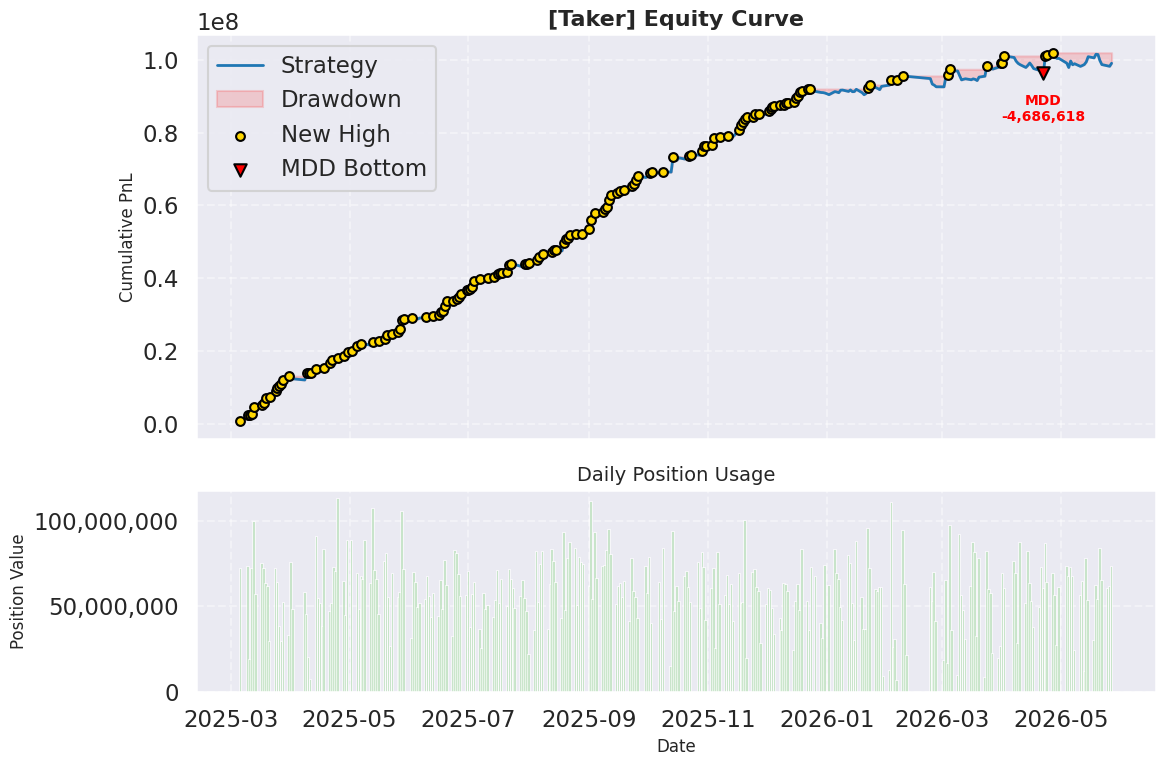


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 9,902.12
近一年報酬（萬）      : 6,981.24
風報比                  : 21.13
年化 Sharpe          : 6.51
創高最長費時 (天)     : 21
平均每日交易商品數   : 44.68

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 136.59%
近一年報酬率（近一年平均部位）: 120.55%
勝率 (日/單筆)      : 63.64% / 65.67%
平均BP (單筆/單位) : 65.33 / 56.9122

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -165.87 萬
MDD金額/佔平均比   : -468.66 萬 / 8.00%
平均/最大部位(萬)  : 5,858.23 / 11,239.57
平均最大單一商品比  : 4.29%



In [58]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

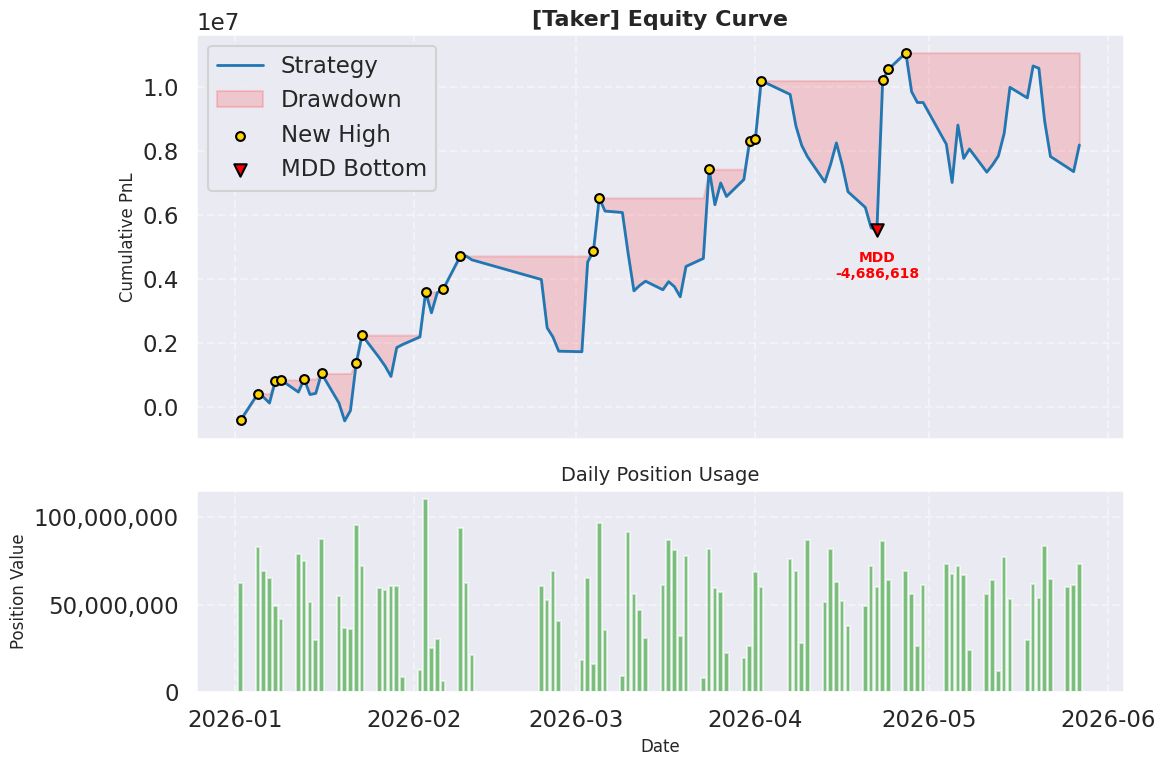


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 818.81
近一年報酬（萬）      : 818.81
風報比                  : 1.75
年化 Sharpe          : 1.41
創高最長費時 (天)     : 21
平均每日交易商品數   : 40.43

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 37.98%
近一年報酬率（近一年平均部位）: 14.72%
勝率 (日/單筆)      : 46.24% / 55.56%
平均BP (單筆/單位) : 29.05 / 15.8234

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -165.87 萬
MDD金額/佔平均比   : -468.66 萬 / 8.42%
平均/最大部位(萬)  : 5,564.16 / 11,024.27
平均最大單一商品比  : 5.22%



In [59]:
bt = BackTest(signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) > 20260101 )])
results = bt.run_analysis()
daily_ticker_df = bt.get_daily_ticker_result()

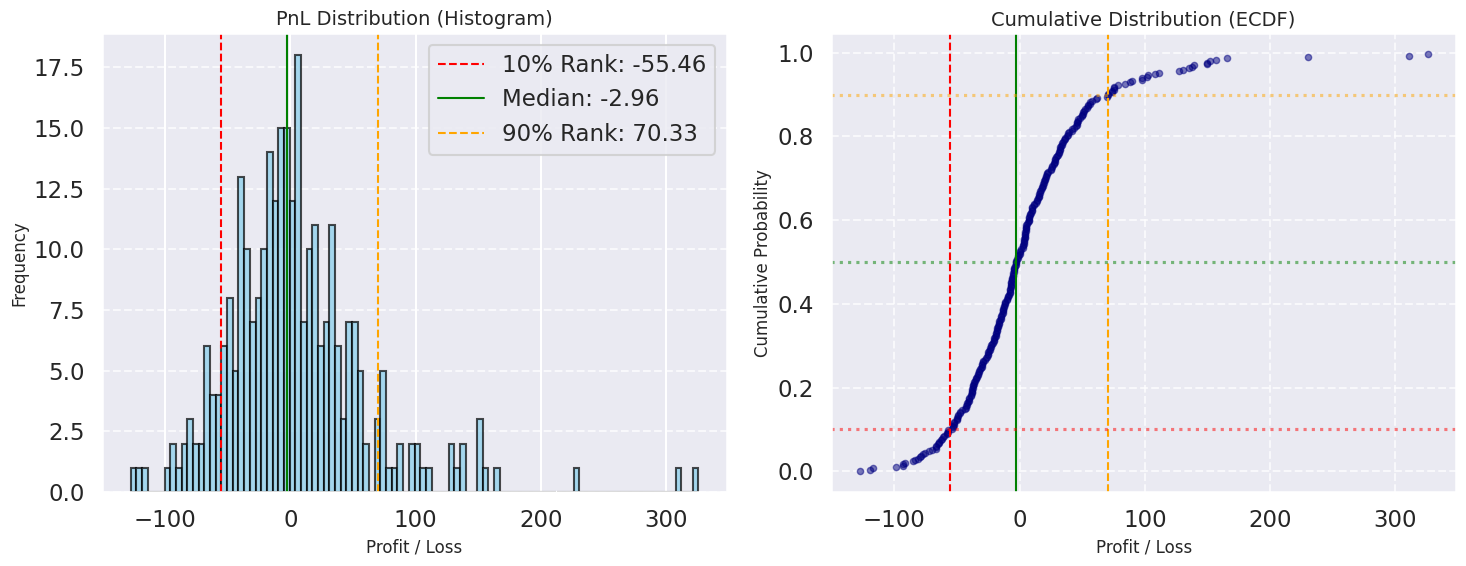

In [30]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [31]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [32]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

date_portfolio.to_csv('當前模型.csv')

In [33]:
dayReturn_all = []
etf_list = ['00981A', '00982A', '00947', '00992A','0050', '00631L']
for d in date_portfolio.Date : 
    etf_temp = pd.read_parquet(f'/home/kevin/Project/HFT/data/marketData/{d}_marketData.parquet')
    dayReturn = [ d ]
    
    for qc in etf_list :
        try : 
            qc_temp = etf_temp[etf_temp.quote_code.str.contains(qc)].iloc[0]
            dayReturn.append( (qc_temp.close_price - qc_temp.opening_ref_price) / qc_temp.opening_ref_price )
        except : 
            dayReturn.append(0)
    dayReturn_all.append( dayReturn )


In [34]:
dayReturn_all = pd.DataFrame( columns= ['date']+etf_list, data = np.array(dayReturn_all) )


In [35]:
try :
    for c in dayReturn_all.columns[1:] : 
        dayReturn_all[c] = dayReturn_all[c].astype(float)
except : 
    pass
dayReturn_all.describe()

,00981A,00982A,00947,00992A,0050,00631L
count,295.000000,295.000000,296.000000,295.000000,291.000000,292.000000
mean,0.004139,0.003403,0.004231,0.002189,0.003294,0.005632
std,0.017960,0.016503,0.023591,0.015292,0.015757,0.031544
min,-0.071790,-0.064475,-0.074613,-0.075733,-0.046003,-0.112012
25%,-0.003511,-0.002710,-0.008488,0.000000,-0.006261,-0.011629
50%,0.000000,0.000946,0.002848,0.000000,0.001652,0.003693
75%,0.014187,0.012506,0.017487,0.000000,0.011810,0.021356
max,0.070395,0.054778,0.099312,0.071482,0.099863,0.199684


【分析 A】2025 以後 兩者報酬與風險特性：
- 獲利率 Pearson 相關性: -0.3354
- 0030_portfolio  : 日波動 1.5757 | 年化波動度 25.0134
- date_portfolio  : 日波動 1.4267 | 年化波動度 22.6478

【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：
- 在 0030_portfolio 最差的 59 天中，有 13.56% 的機率 date_portfolio 也處於極端虧損
- 在 date_portfolio 最差的 60 天中，有 13.33% 的機率 0030 也處於極端虧損



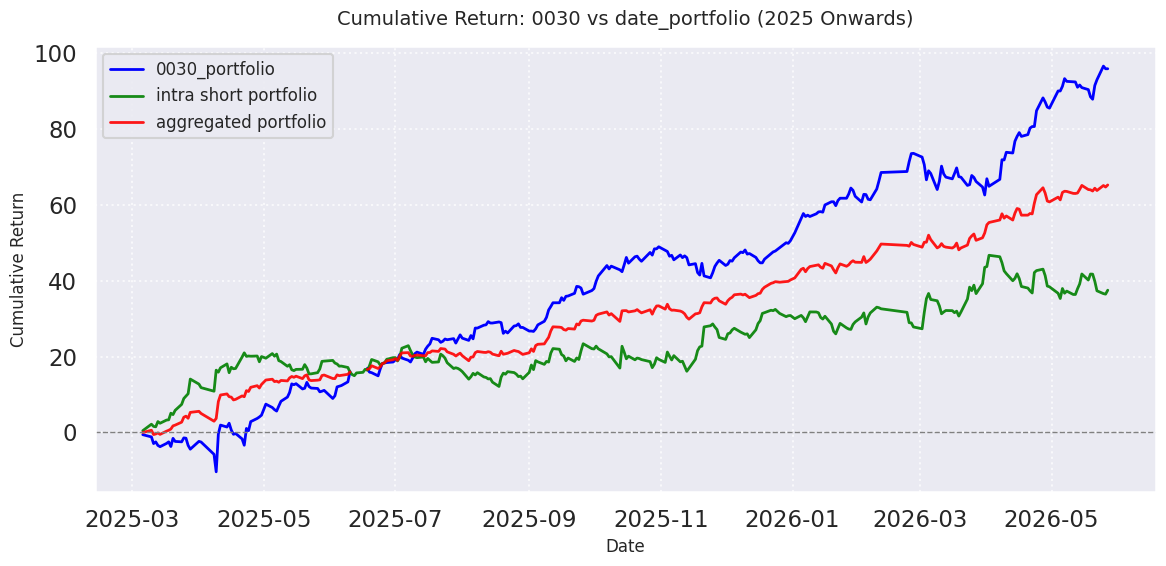

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 讀取並處理 0030_portfolio.csv
# -------------------------------------------------------------------------
# df_0030 = pd.read_csv('/home/kevin/Project/HFT/src/research/negFill/0030_portfolio.csv', encoding='utf-8-sig')

# # 將 0030 的日期轉為 datetime 格式，方便後續篩選
# df_0030['日期'] = pd.to_datetime(df_0030['日期'].astype(str), format='%Y%m%d')

# # 👉 更正 1：篩選 2025 以後（包含 2025-01-01）
# df_0030_filtered = df_0030[df_0030['日期'] >= '2025-01-01'].copy()
# df_0030_filtered['獲利率'] = df_0030_filtered['獲利率'] * 100


df_0030 = dayReturn_all.copy()
df_0030['日期'] = pd.to_datetime(df_0030['date'].astype(str), format='%Y%m%d')
df_0030_filtered = df_0030[df_0030['日期'] >= '2023-01-01'].copy()

target = '0050'
# + 0.00143*(df_0030_filtered[target]!= 0) 
df_0030_filtered['獲利率'] = (df_0030_filtered[target].astype(float) ) * 100

# -------------------------------------------------------------------------
# 2. 處理 date_portfolio，對齊年份與格式
# -------------------------------------------------------------------------
# 👉 請確認這兩個變數對應您 date_portfolio 的實際欄位名稱：
date_col = 'Date'        # 日期欄位名稱
return_col = 'Return'    # 獲利率欄位名稱

dp_filtered = date_portfolio.copy()

# 若 date_portfolio 的日期在 index 上，請解除下面這行註解：
# dp_filtered = dp_filtered.reset_index() 

# 將該欄位轉為 datetime 格式，並篩選 2025 以後的資料
dp_filtered[date_col] = pd.to_datetime(dp_filtered[date_col].astype(str)) 
dp_filtered = dp_filtered[dp_filtered[date_col] >= '2023-01-01'].copy()


# -------------------------------------------------------------------------
# 合併兩者（取每日均有交易的交集日），並確保日期順序
# -------------------------------------------------------------------------
merged_df = pd.merge(
    df_0030_filtered[['日期', '獲利率']], 
    dp_filtered[[date_col, return_col]], 
    left_on='日期', 
    right_on=date_col, 
    how='inner'
)
merged_df = merged_df.sort_values('日期').reset_index(drop=True)


# =========================================================
# 分析 A：獲利率相關性與波動度
# =========================================================
correlation = merged_df['獲利率'].corr(merged_df[return_col])

# 👉 新增 2：計算波動度 (日標準差及乘上根號 252 的年化標準差)
vol_0030_daily = merged_df['獲利率'].std()
vol_0030_annual = vol_0030_daily * np.sqrt(252)

vol_dp_daily = merged_df[return_col].std()
vol_dp_annual = vol_dp_daily * np.sqrt(252)

print("【分析 A】2025 以後 兩者報酬與風險特性：")
print(f"- 獲利率 Pearson 相關性: {correlation:.4f}")
print(f"- 0030_portfolio  : 日波動 {vol_0030_daily:.4f} | 年化波動度 {vol_0030_annual:.4f}")
print(f"- date_portfolio  : 日波動 {vol_dp_daily:.4f} | 年化波動度 {vol_dp_annual:.4f}\n")
flucRate = vol_0030_annual/ vol_dp_annual


# =========================================================
# 分析 B：各自賠最多的 20% 交易日的重疊率 (基於原始 2025 以後的區間)
# =========================================================
thresh_0030 = df_0030_filtered['獲利率'].quantile(0.2)
thresh_dp = dp_filtered[return_col].quantile(0.2)

worst_days_0030 = set(df_0030_filtered[df_0030_filtered['獲利率'] <= thresh_0030]['日期'])
worst_days_dp = set(dp_filtered[dp_filtered[return_col] <= thresh_dp][date_col])

overlap_days = worst_days_0030.intersection(worst_days_dp)
union_days = worst_days_0030.union(worst_days_dp)

rate_0030 = len(overlap_days) / len(worst_days_0030) if len(worst_days_0030) > 0 else 0
rate_dp = len(overlap_days) / len(worst_days_dp) if len(worst_days_dp) > 0 else 0

print("【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：")
print(f"- 在 0030_portfolio 最差的 {len(worst_days_0030)} 天中，有 {rate_0030:.2%} 的機率 date_portfolio 也處於極端虧損")
print(f"- 在 date_portfolio 最差的 {len(worst_days_dp)} 天中，有 {rate_dp:.2%} 的機率 0030 也處於極端虧損\n")


# =========================================================
# 分析 C：繪製 2025 以後累計獲利率 (CumSum) 比較圖
# =========================================================
# 👉 新增 3：計算 CumSum 並畫在同一張圖
merged_df['0030_cumsum'] = merged_df['獲利率'].cumsum()
merged_df['dp_cumsum'] = merged_df[return_col].cumsum()

plt.figure(figsize=(12, 6))

# 把累進獲利畫出來
plt.plot(merged_df['日期'], merged_df['0030_cumsum'], label='0030_portfolio', color='blue', linewidth=2)
plt.plot(merged_df['日期'], merged_df['dp_cumsum'], label='intra short portfolio', color='green', linewidth=2, alpha=0.9)
plt.plot(merged_df['日期'],  (merged_df['0030_cumsum'] + merged_df['dp_cumsum']*flucRate) / (1+flucRate), label='aggregated portfolio', color='red', linewidth=2, alpha=0.9)

# 圖表美化
plt.title('Cumulative Return: 0030 vs date_portfolio (2025 Onwards)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 補上 0 軸線方便看有沒有賺錢
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# 調整佈局並顯示
plt.tight_layout()
plt.show()



In [37]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import polars as pl
from tqdm import tqdm

PROJECT_ROOT = Path(os.path.abspath('')).parents[2]

import glob
# ======================================================================
# 1. 預先計算台積電 (2330) 的歷史季線 (60MA)
# (加入防呆機制，跳過欄位毀損的日期檔案，避免 SchemaError 崩潰)
# ======================================================================
print("預先計算台積電 60MA 中...")
files = glob.glob(f'{PROJECT_ROOT}/data/marketData/*_marketData.parquet')
dfs = []
for f in tqdm(files, desc="讀取台積電歷史"):
    try:
        # 只讀取需要的欄位並且立刻過濾 2330，節省大量記憶體！
        df_day = pl.read_parquet(f, columns=['date', 'quote_code', 'close_price'])
        tsmc_day = df_day.filter(pl.col('quote_code') == '2330')
        dfs.append(tsmc_day)
    except Exception as e:
        # 遇到破掉或缺少欄位的假期檔案直接略過
        pass
# 將所有天數合併並照日期排序
tsmc_hist = pl.concat(dfs, how="diagonal_relaxed").sort('date').to_pandas()
# 計算 60 天移動平均線 (季線)
tsmc_hist['MA60'] = tsmc_hist['close_price'].rolling(window=60).mean()
# 轉成字串字典
tsmc_hist['date_str'] = pd.to_datetime(tsmc_hist['date']).dt.strftime('%Y%m%d')
tsmc_ma60_dict = dict(zip(tsmc_hist['date_str'], tsmc_hist['MA60']))
# ======================================================================

# ======================================================================
# 2. 開始執行你的主要迴圈
# ======================================================================
dateData = []
for d in tqdm( date_portfolio.Date[:-1] ): 
    # 轉為字串以防找不到，請依據你 df 中 date 的實際樣子調整
    d_str = str(d).replace("-", "") 
    
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d_str}_marketData.parquet')
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d_str}_preMarketData.parquet')
    
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    # 取出 2330
    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    tsmcClose = tsmc.close_price.iloc[0]
    
    # ======== 新增：計算距離季線(60MA)的乖離幅度 ========
    # 從剛剛預先做好的字典取出當天的 60MA
    ma60_today = tsmc_ma60_dict.get(d_str)
    
    if pd.notna(ma60_today) and ma60_today > 0:
        # 乖離率 = (收盤價 - 季線) / 季線
        tsmc_dist_60MA = (tsmcClose - ma60_today) / ma60_today
    else:
        # 前 60 天資料不足時先填空
        tsmc_dist_60MA = np.nan 
    # ===================================================

    merged_df['dayReturnRank'] = ((merged_df.close_price - merged_df.open_price) / merged_df.open_price).groupby([merged_df.ins_type, merged_df.date, merged_df.market]).rank(pct=True)
    merged_df['market_capRank']=(merged_df.market_cap ).groupby([merged_df.ins_type, merged_df.date, merged_df.market]).rank(pct=True)
    # day_amount_rank < 100 的 mean
    top_df = merged_df[ (merged_df['day_amount_rank'] <= 100) & (merged_df.allow_day_trade_mark_x == 'X')]
    otcHotCap = merged_df[lambda x : (x.day_amount_rank > 0) & (x.dayReturnRank > 0.9) & (x.market == 'otc')].market_capRank.mean()
    listHotCap = merged_df[lambda x : (x.day_amount_rank > 0) & (x.dayReturnRank > 0.9) & (x.market == 'tse')].market_capRank.mean()
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topCount = top_df.toOpen.count()
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)

    
    # 將算出的距離季線報酬率 (tsmc_dist_60MA) 塞進 dateData 中
    dateData.append([tsmcOpen, tsmcReturn, tsmc_dist_60MA, topOpen, topDrop, topReturn, topCount,otcHotCap, listHotCap])



預先計算台積電 60MA 中...


100%|██████████| 295/295 [00:12<00:00, 23.09it/s]


In [38]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [39]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'tsmc_dist_60MA', 'topOpen', 'topDrop', 'topReturn','topCount','otcHotCap', 'listHotCap'], data = dateData) ], axis = 1)

<Axes: xlabel='Date'>

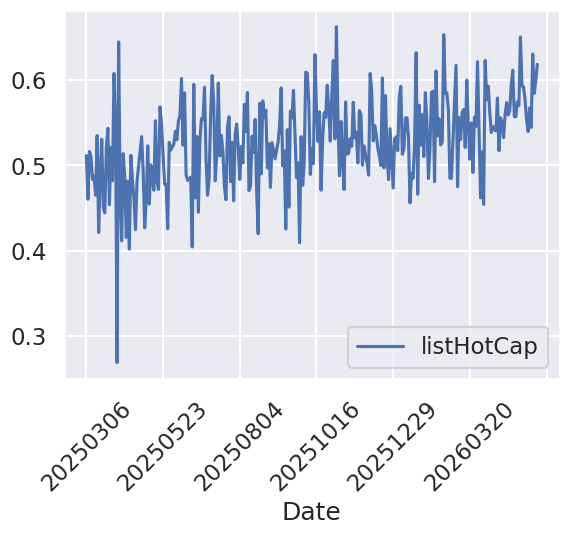

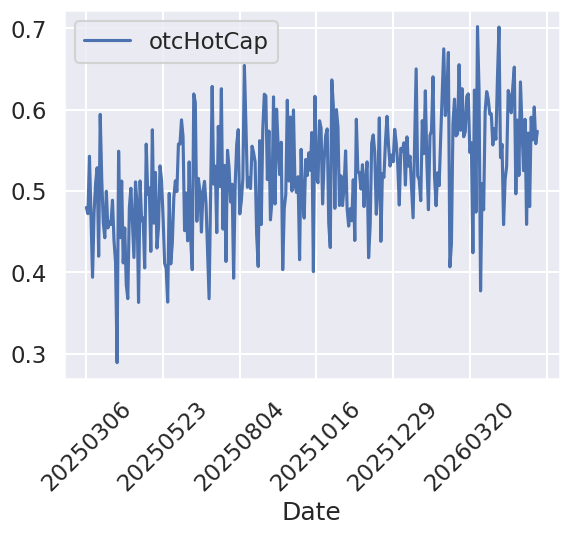

In [40]:
date_portfolio.plot(x='Date', y='listHotCap', rot=45)
date_portfolio.plot(x='Date', y='otcHotCap', rot=45)

In [41]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [42]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(10,min_periods=1).std().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()

In [43]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0025) #| (date_portfolio.topReturnlast_10D > 0.015) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [44]:
date_portfolio[['Date', 'topOpen']].to_csv('open.csv')

In [45]:
date_portfolio['Count'].mean()

np.float64(0.34121621621621623)

<Axes: >

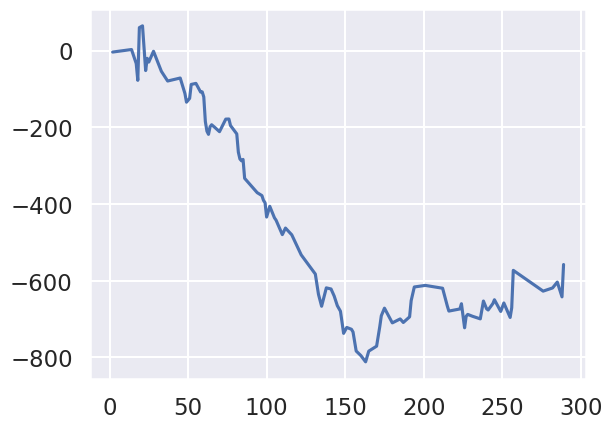

In [46]:
date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
# date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

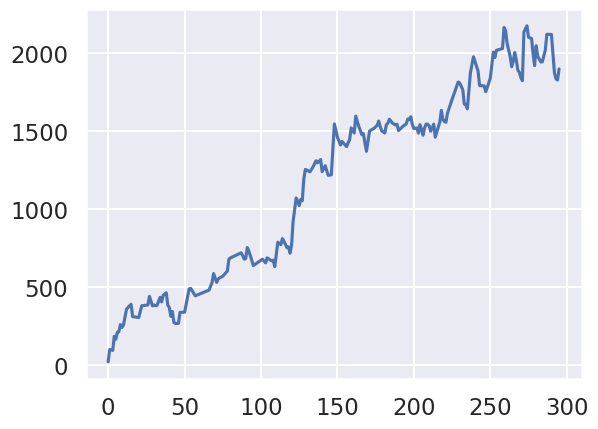

In [47]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [48]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==1) ].Date.to_list()

In [49]:
date_portfolio

,Date,PL,Position,Return,tsmOpen,tsmReturn,tsmc_dist_60MA,topOpen,topDrop,topReturn,topCount,otcHotCap,listHotCap,topStd_10D,topReturnlast_10D,Count
0,20250306,20.108505,4490.930,0.447758,0.000000,-0.014706,-0.069157,0.007230,0.489796,-0.003963,98.0,0.479903,0.511480,NaN,NaN,False
1,20250310,78.747452,4623.600,1.703163,0.000000,-0.006965,-0.074398,0.010831,0.574468,-0.003606,94.0,0.472260,0.460313,NaN,NaN,False
2,20250311,-4.008659,691.015,-0.580112,-0.029058,-0.027054,-0.098059,-0.025393,-0.808511,-0.012050,94.0,0.542913,0.516246,0.059872,0.000253,True
3,20250312,-5.162874,5044.080,-0.102355,0.009269,0.017508,-0.081030,0.004973,0.505263,0.005225,95.0,0.469837,0.510016,0.775177,0.004776,False
4,20250313,89.925727,6537.240,1.375592,0.012146,-0.023279,-0.101029,0.016184,0.840426,-0.004777,94.0,0.394140,0.483656,0.666860,0.007057,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,20260521,-119.606232,6391.830,-1.871236,0.025172,0.020595,0.104872,0.035026,0.967742,0.045901,93.0,0.563007,0.630379,0.580402,0.020330,False
292,20260522,-127.550669,5059.725,-2.520901,0.006726,0.011211,0.113993,0.024668,0.781250,0.042268,96.0,0.603491,0.584156,0.608047,0.024232,False
293,20260525,-37.518846,5049.765,-0.742982,0.008869,0.024390,0.137931,0.034856,0.904255,0.040164,94.0,0.558255,0.599371,0.606716,0.026465,False
294,20260526,-6.686823,4988.820,-0.134036,0.004329,-0.017316,0.115890,0.017167,0.804348,0.012325,92.0,0.573492,0.618202,0.628160,0.027033,False


In [50]:
date_portfolio['otcHotCap'] = date_portfolio['otcHotCap'].shift()
date_portfolio['listHotCap'] = date_portfolio['listHotCap'].shift()

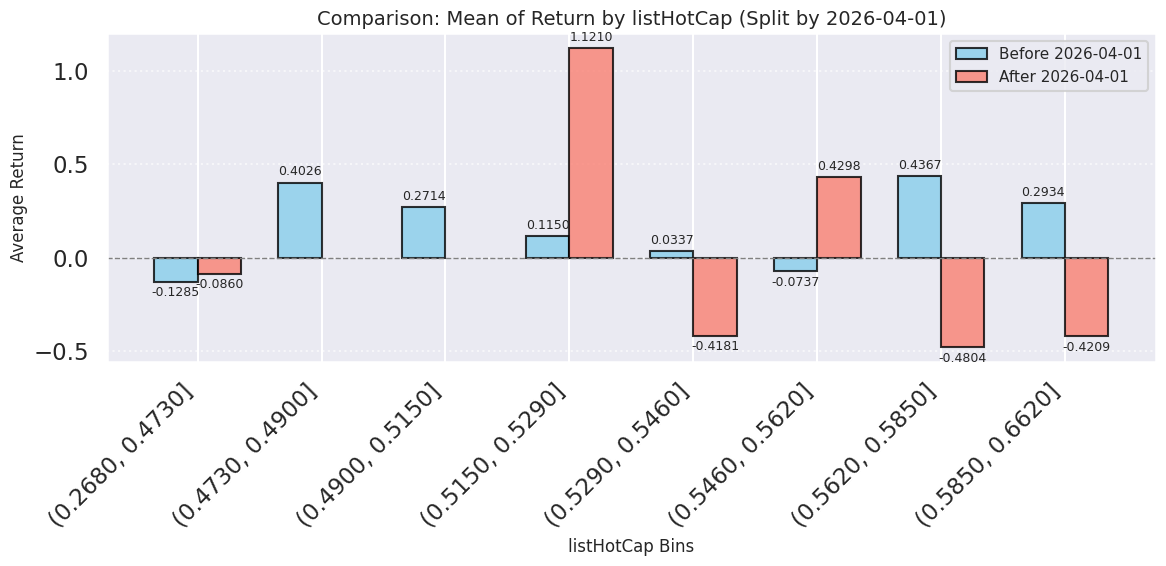

In [51]:
QcutAnalyzer.plot_qcut_analysis(date_portfolio, 'listHotCap', 'Return', date_col='Date', split_date='2026-04-01', q=8)


import json

# 假設這是你的異常日期清單 (字串格式)

# 將 list 存成 JSON 檔案
with open('abnormal_dates.json', 'w') as f:
    json.dump(abonraml_DATE, f)
    
print("異常日期清單已儲存！")

In [52]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'